In [1]:
import os
import re
import numpy as np
import pandas as pd
from mt_metadata.transfer_functions import TF

def get_sitename(edi_path):
    with open(edi_path, "r", errors="ignore") as f:
        for line in f:
            if "SITENAME" in line:
                return line.split("=")[1].strip().strip('"')
    return os.path.basename(edi_path).split(".")[0]

def sanitize_edi(edi_path):
    with open(edi_path, "r", errors="ignore") as f:
        lines = f.readlines()

    cleaned = []
    for line in lines:
        if line.strip().startswith(">!"):
            cleaned.append(line)
            continue

        line = re.sub(r"\*+", " -9999 ", line)
        line = re.sub(r"(?<![0-9eE\+\-])0\.0(?![0-9eE\+\-])", " -9999 ", line)

        cleaned.append(line)

    return "".join(cleaned)


def compute_skew(edi_path):
    try:
        txt = sanitize_edi(edi_path)
        tmpfile = "_tmp_clean.edi"
        with open(tmpfile, "w", errors="ignore") as f:
            f.write(txt)

        tf = TF()
        tf.read(fn=tmpfile)

        Z = np.array(tf.impedance.data, dtype=float)
        Z[Z == -9999] = np.nan

        Zxx, Zxy, Zyx, Zyy = Z[:,0,0], Z[:,0,1], Z[:,1,0], Z[:,1,1]
        skew = np.abs(Zxx + Zyy) / np.abs(Zxy - Zyx)
        skew = skew[np.isfinite(skew)]

        return np.nanmean(skew) if len(skew) > 0 else np.nan

    except Exception:
        return np.nan


folder = "../data/all_station_EDI_data"

records = []

for fname in os.listdir(folder):
    if fname.lower().endswith(".edi"):
        path = os.path.join(folder, fname)

        site = get_sitename(path)
        skew_val = compute_skew(path)

        records.append((site, fname, skew_val))

# ---------------------------------------------------
# NOW: one skew classification per file
# ---------------------------------------------------
df = pd.DataFrame(records, columns=["Site", "File", "Skew"])

# mark 1D-like for each EDI file
df["Is1D"] = df["Skew"] < 0.5

# sort by skew
df = df.sort_values("Skew", ascending=True).reset_index(drop=True)

print(df.to_string(index=False))

df.to_csv("each_file_skew_classification.csv", index=False)


C:\Users\shail\AppData\Local\Temp\ipykernel_9624\1116426052.py:42: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_9624\1116426052.py:42: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_9624\1116426052.py:42: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_9624\1116426052.py:42: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_9624\1116426052.py:42: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
C:\Users\shail\AppData\Local\Temp\ipykernel_9624\111642

                                   Site                                 File       Skew  Is1D
                Kimberley, South Africa               SAMTEX.kim420.2004.edi   0.028470  True
                       Botswana, Africa               SAMTEX.mof112.2005.edi   0.028825  True
                       Botswana, Africa               SAMTEX.bot407.2005.edi   0.029292  True
                Kimberley, South Africa               SAMTEX.kim423.2004.edi   0.029474  True
                Kimberley, South Africa               SAMTEX.kim429.2004.edi   0.032595  True
                Kimberley, South Africa          SAMTEX.kim314.2003-2006.edi   0.033218  True
                Kimberley, South Africa               SAMTEX.kim430.2004.edi   0.033335  True
Kalahari Game Reserve, Botswana, Africa               SAMTEX.kal019.2008.edi   0.033698  True
                       Botswana, Africa               SAMTEX.mof107.2005.edi   0.034948  True
                Kimberley, South Africa               SAMTEX

In [4]:
# ---------------------------------------
# EXTENDED SKEW FREQUENCY DISTRIBUTION
# up to > 2.0
# ---------------------------------------

bins = [
    -np.inf, 0.2, 0.3, 0.4, 0.5,
    0.6, 0.7, 0.8, 0.9, 1.0,
    1.1, 1.2, 1.3, 1.4, 1.5,
    1.6, 1.7, 1.8, 1.9, 2.0,
    np.inf
]

labels = [
    "< 0.2",
    "0.2–0.3",
    "0.3–0.4",
    "0.4–0.5",
    "0.5–0.6",
    "0.6–0.7",
    "0.7–0.8",
    "0.8–0.9",
    "0.9–1.0",
    "1.0–1.1",
    "1.1–1.2",
    "1.2–1.3",
    "1.3–1.4",
    "1.4–1.5",
    "1.5–1.6",
    "1.6–1.7",
    "1.7–1.8",
    "1.8–1.9",
    "1.9–2.0",
    "> 2.0"
]

df["SkewRange"] = pd.cut(df["Skew"], bins=bins, labels=labels, right=True)

freq_table = df["SkewRange"].value_counts().sort_index()

print("\nSkew Frequency Distribution:")
for label, count in freq_table.items():
    print(f"{label} = {count} stations")



Skew Frequency Distribution:
< 0.2 = 293 stations
0.2–0.3 = 115 stations
0.3–0.4 = 92 stations
0.4–0.5 = 45 stations
0.5–0.6 = 49 stations
0.6–0.7 = 28 stations
0.7–0.8 = 13 stations
0.8–0.9 = 21 stations
0.9–1.0 = 14 stations
1.0–1.1 = 17 stations
1.1–1.2 = 11 stations
1.2–1.3 = 8 stations
1.3–1.4 = 6 stations
1.4–1.5 = 7 stations
1.5–1.6 = 6 stations
1.6–1.7 = 4 stations
1.7–1.8 = 4 stations
1.8–1.9 = 3 stations
1.9–2.0 = 5 stations
> 2.0 = 43 stations


In [15]:
# ---------------------------------------
# STATION-LEVEL SUMMARY (PER EDI FILE)
# ---------------------------------------

total_stations = len(df)
total_1d_like_stations = (df["Skew"] < 0.6).sum()
total_rejected_stations = total_stations - total_1d_like_stations

print("\nStation Summary:")
print("Total Stations:", total_stations)
print("Total 1D-like Stations:", total_1d_like_stations)
print("Total Rejected Stations:", total_rejected_stations)



Station Summary:
Total Stations: 784
Total 1D-like Stations: 594
Total Rejected Stations: 190


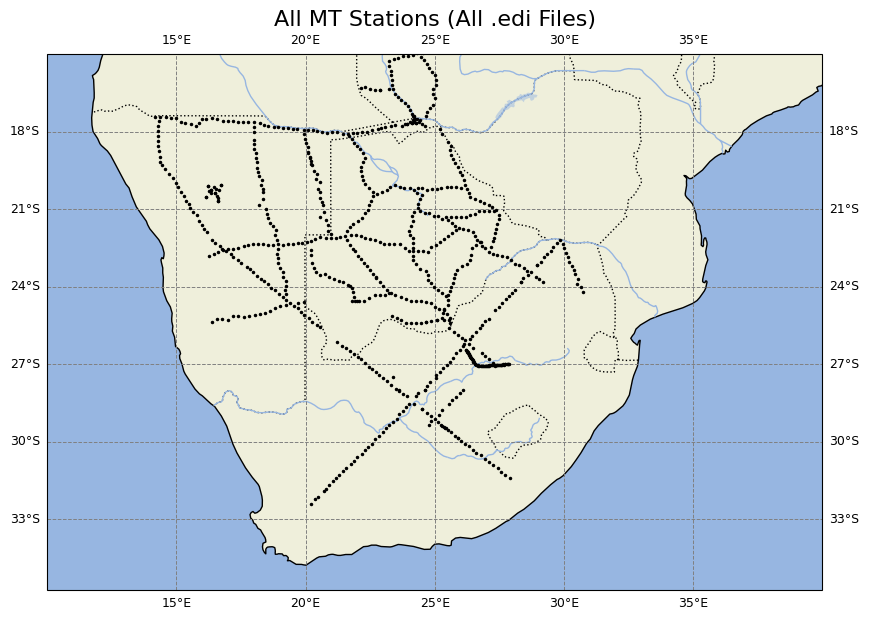

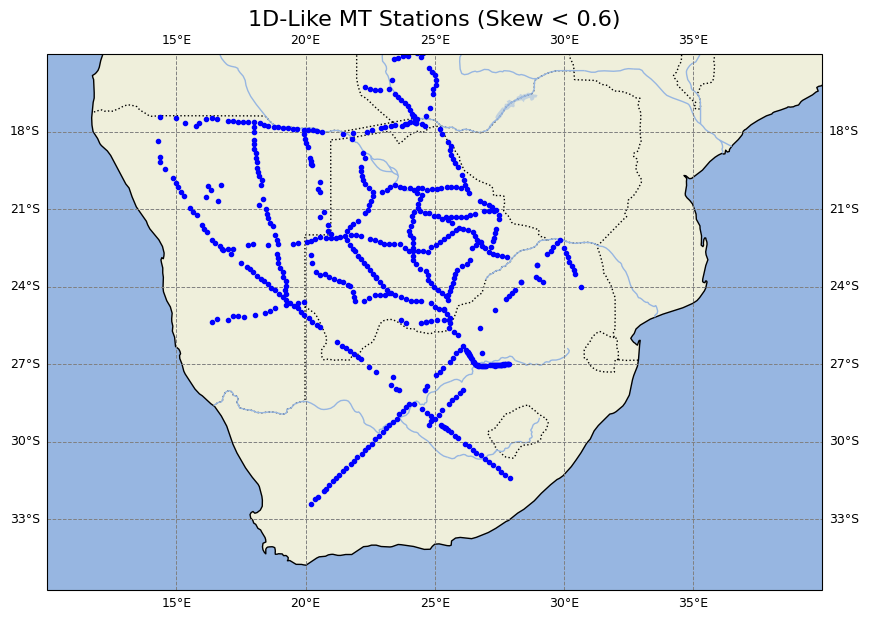

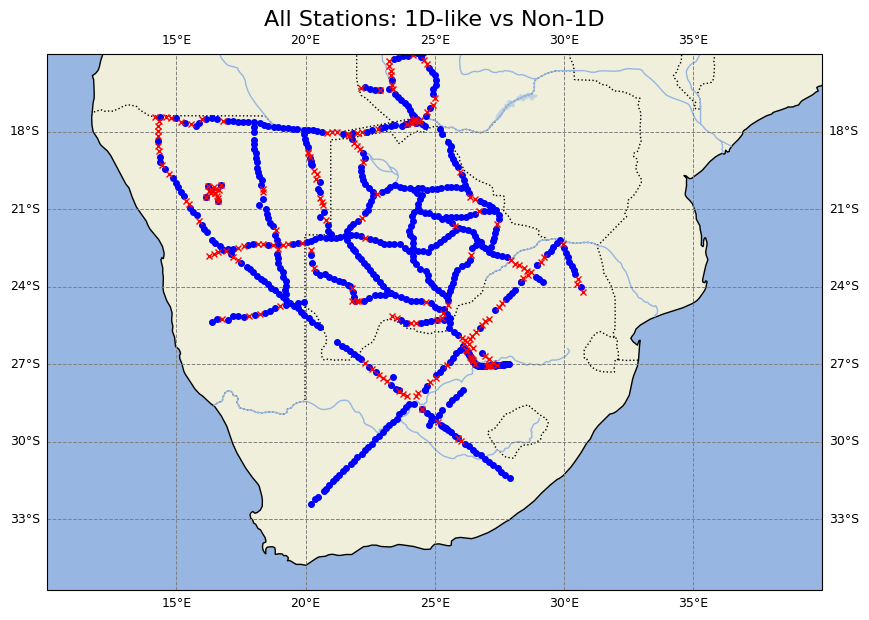

In [22]:
import re
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ----------------------------------------------------
# EXTRACT LAT / LONG FOR EACH STATION (EACH EDI FILE)
# ----------------------------------------------------
def extract_lat_lon(edi_path):

    def dms_to_dd(dms):
        try:
            sign = -1 if dms.strip().startswith("-") else 1
            parts = dms.replace("-", "").split(":")
            deg, minutes, seconds = map(float, parts)
            return sign * (deg + minutes/60 + seconds/3600)
        except:
            return np.nan

    lat, lon = np.nan, np.nan

    with open(edi_path, "r", errors="ignore") as f:
        for line in f:
            if line.strip().startswith("LAT="):
                lat = dms_to_dd(line.split("=")[1].strip())
            if line.strip().startswith("LONG="):
                lon = dms_to_dd(line.split("=")[1].strip())

    return lat, lon


# ----------------------------------------------------
# BUILD TABLE: station-level (each EDI file)
# ----------------------------------------------------
records_with_geo = []

for idx, row in df.iterrows():
    fname = row["File"]
    path = os.path.join(folder, fname)

    lat, lon = extract_lat_lon(path)
    records_with_geo.append((row["Site"], fname, row["Skew"], lat, lon))

geo_df = pd.DataFrame(records_with_geo,
                      columns=["Site", "File", "Skew", "Lat", "Lon"])

# classification
geo_df["Is1D"] = geo_df["Skew"] < 0.6

good_stations = geo_df[geo_df["Is1D"] == True]
bad_stations  = geo_df[geo_df["Is1D"] == False]


# ----------------------------------------------------
# MAP TEMPLATE FUNCTION
# ----------------------------------------------------
def setup_map(title):
    plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([10, 40, -35, -15])    # Southern Africa

    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.OCEAN)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.LAKES, alpha=0.5)
    ax.add_feature(cfeature.RIVERS)

    gl = ax.gridlines(draw_labels=True,
                      linewidth=0.7,
                      linestyle='--',
                      color='gray')

    gl.top_labels = True
    gl.bottom_labels = True
    gl.left_labels = True
    gl.right_labels = True

    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}

    plt.title(title, fontsize=16)
    return ax


# ----------------------------------------------------
# IMAGE 1: ALL STATIONS (ALL .edi FILES)
# ----------------------------------------------------
ax = setup_map("All MT Stations (All .edi Files)")
for _, row in geo_df.iterrows():
    ax.plot(row["Lon"], row["Lat"],
            'k.', markersize=3,
            transform=ccrs.PlateCarree())
plt.show()


# ----------------------------------------------------
# IMAGE 2: ONLY 1D-LIKE STATIONS
# ----------------------------------------------------
ax = setup_map("1D-Like MT Stations (Skew < 0.6)")
for _, row in good_stations.iterrows():
    ax.plot(row["Lon"], row["Lat"],
            'bo', markersize=3,
            transform=ccrs.PlateCarree())
plt.show()


# ----------------------------------------------------
# IMAGE 3: ALL STATIONS, 1D VS NON-1D
# ----------------------------------------------------
ax = setup_map("All Stations: 1D-like vs Non-1D")

# Plot 1D-like (blue circles)
for _, row in good_stations.iterrows():
    ax.plot(row["Lon"], row["Lat"],
            marker='o',
            markersize=4,
            color='blue',
            transform=ccrs.PlateCarree())

# Plot non-1D (red crosses)
for _, row in bad_stations.iterrows():
    ax.plot(row["Lon"], row["Lat"],
            marker='x',
            markersize=5,
            color='red',
            transform=ccrs.PlateCarree())

plt.show()


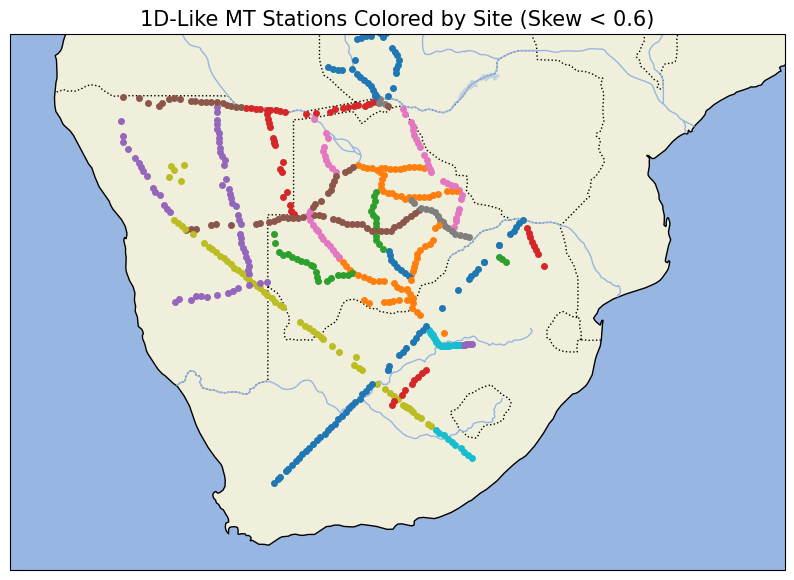


Color Name → Site Mapping:
Barotse Basin, Western Province, Zambia : tab:blue
Botswana, Africa : tab:orange
Central Botswana, Africa : tab:green
Coffiefontain, South Africa : tab:red
Hardap Region, Namibia, Africa : tab:purple
Kalahari Game Reserve, Botswana, Africa : tab:brown
Kang to Ghazi, Botswana, Africa : tab:pink
Kasane, Zimbabwe, Africa : tab:gray
Kimberley, South Africa : tab:olive
Klerksdorp, South Africa : tab:cyan
Kweneng, Botswana, Africa : tab:blue
Makgadikgadi Park, Botswana, Africa : tab:orange
Mokopane, South Africa : tab:green
NE Namibia, Africa : tab:red
Namibia, Africa : tab:purple
Northern Namibia, Africa : tab:brown
Okavango Lake, Botswana, Africa : tab:pink
Orapa, Botswana, Africa : tab:gray
Otjiwarongo, Namibia, Africa : tab:olive
Smithfield, South Africa : tab:cyan
South Africa : tab:blue
Southern Botswana, Africa : tab:orange
Tshane, Botswana, Africa : tab:green
Tzaneen, South Africa : tab:red
Weiveld, South Africa : tab:purple
Windhoek, Namibia, Africa : tab

In [20]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ----------------------------------------------------
# FILTER ONLY 1D-LIKE STATIONS
# ----------------------------------------------------
good_stations = geo_df[geo_df["Skew"] < 0.6].copy()
good_sites = sorted(good_stations["Site"].unique())

# ----------------------------------------------------
# USE DARK, HIGH-CONTRAST NAMED COLORS
# ----------------------------------------------------
named_colors = list(mcolors.TABLEAU_COLORS.keys())  
num_colors = len(named_colors)

repeat_factor = int(np.ceil(len(good_sites) / num_colors))
final_named_colors = (named_colors * repeat_factor)[:len(good_sites)]

site_color_map = dict(zip(good_sites, final_named_colors))

# convert names → actual color values for plotting
site_plot_color = {s: mcolors.TABLEAU_COLORS[c] for s, c in site_color_map.items()}

# ----------------------------------------------------
# PLOT MAP
# ----------------------------------------------------
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([10, 40, -35, -15])

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS)

# ----------------------------------------------------
# PLOT ALL STATIONS ONLY (NO CENTER HIGHLIGHT)
# ----------------------------------------------------
for _, row in good_stations.iterrows():
    site = row["Site"]
    color = site_plot_color[site]

    ax.plot(
        row["Lon"], row["Lat"],
        marker="o",
        markersize=4,
        color=color,
        transform=ccrs.PlateCarree(),
    )

plt.title("1D-Like MT Stations Colored by Site (Skew < 0.6)", fontsize=15)
plt.show()

# ----------------------------------------------------
# LEGEND PRINT
# ----------------------------------------------------
print("\nColor Name → Site Mapping:")
for site, color_name in site_color_map.items():
    print(f"{site} : {color_name}")


Loaded Cratons: 3 features
Loaded Faults: 104 features
Loaded Volcanics: 7 features


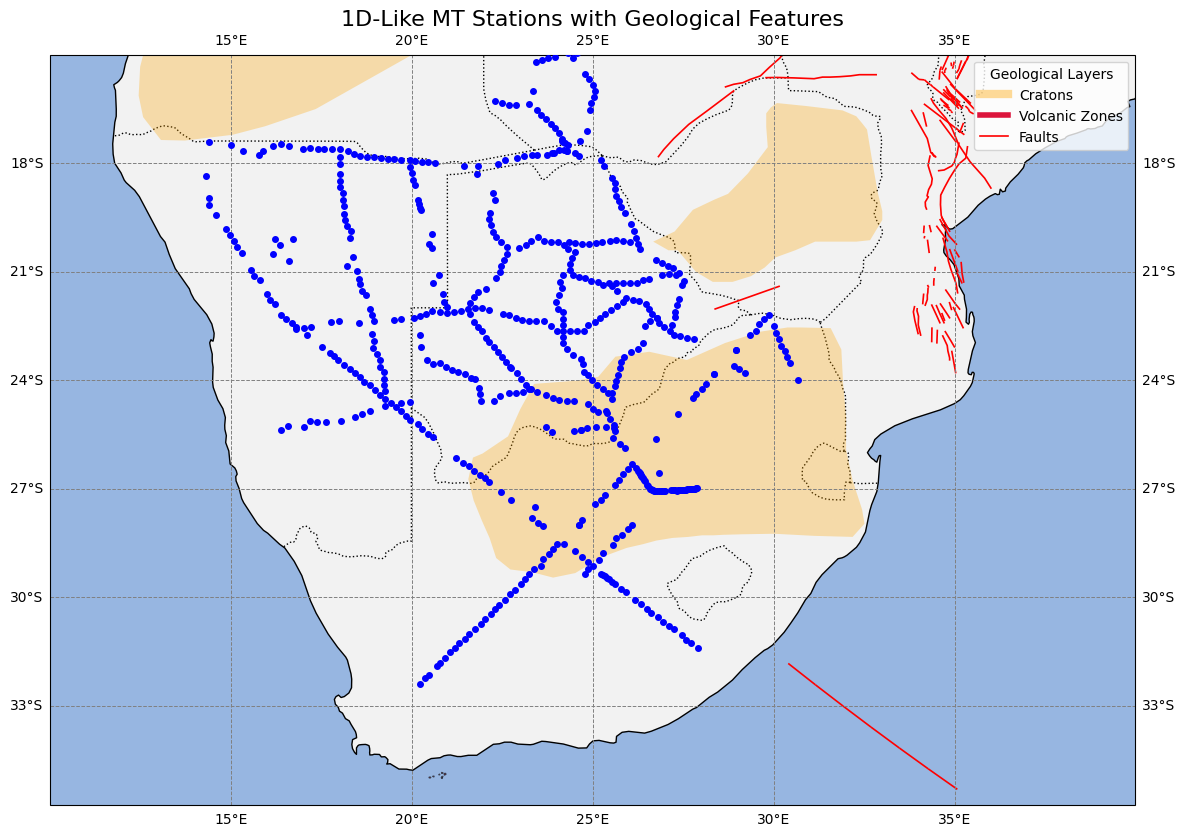

In [24]:
import re
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from cartopy.feature import ShapelyFeature
import os

# ----------------------------------------------------
# EXTRACT LAT / LONG FOR EACH STATION (EACH EDI FILE)
# ----------------------------------------------------
def extract_lat_lon(edi_path):

    def dms_to_dd(dms):
        try:
            sign = -1 if dms.strip().startswith("-") else 1
            parts = dms.replace("-", "").split(":")
            deg, minutes, seconds = map(float, parts)
            return sign * (deg + minutes/60 + seconds/3600)
        except:
            return np.nan

    lat, lon = np.nan, np.nan

    with open(edi_path, "r", errors="ignore") as f:
        for line in f:
            if line.strip().startswith("LAT="):
                lat = dms_to_dd(line.split("=")[1].strip())
            if line.strip().startswith("LONG="):
                lon = dms_to_dd(line.split("=")[1].strip())

    return lat, lon


# ----------------------------------------------------
# BUILD GEO-DF FOR STATIONS
# ----------------------------------------------------
records = []
for _, row in df.iterrows():
    fname = row["File"]
    path = os.path.join(folder, fname)
    lat, lon = extract_lat_lon(path)
    records.append((row["Site"], fname, row["Skew"], lat, lon))

geo_df = pd.DataFrame(records, columns=["Site", "File", "Skew", "Lat", "Lon"])

# classification
geo_df["Is1D"] = geo_df["Skew"] < 0.6
good_stations = geo_df[geo_df["Is1D"] == True]

# ----------------------------------------------------
# GEOLOGICAL LAYER LOADING (same as your old code)
# ----------------------------------------------------
ZOOM_EXTENT = [10, 40, -35, -15]
DATA_DIR = "data"

def load_layer(path, name):
    if not os.path.exists(path):
        path = "../" + path
        if not os.path.exists(path):
            print(f"⚠ {name} missing: {path}")
            return None
    try:
        gdf = gpd.read_file(path)
        if gdf.crs and gdf.crs.to_string() != "EPSG:4326":
            gdf = gdf.to_crs("EPSG:4326")
        clipped = gdf.cx[ZOOM_EXTENT[0]:ZOOM_EXTENT[1],
                         ZOOM_EXTENT[2]:ZOOM_EXTENT[3]]
        print(f"Loaded {name}: {len(clipped)} features")
        return clipped
    except Exception as e:
        print(f"Error loading {name}: {e}")
        return None

cratons = load_layer(f"{DATA_DIR}/cratons/cratons.shp", "Cratons")
faults  = load_layer(f"{DATA_DIR}/gem-global-active-faults-master/gem-global-active-faults-master/shapefile/gem_active_faults.shp",
                     "Faults")
volcanics = load_layer(f"{DATA_DIR}/volcanics/volcanics.shp", "Volcanics")


# ----------------------------------------------------
# PLOT GEOLOGICAL MAP + 1D STATIONS
# ----------------------------------------------------
plt.figure(figsize=(14, 14))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(ZOOM_EXTENT)

# Base map
ax.add_feature(cfeature.LAND, facecolor="#f2f2f2")
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.COASTLINE)

# Cratons
if cratons is not None and not cratons.empty:
    craton_feat = ShapelyFeature(cratons.geometry, ccrs.PlateCarree(),
                                 facecolor="orange", edgecolor="none", alpha=0.3)
    ax.add_feature(craton_feat)
    ax.plot([], [], color="orange", alpha=0.4, linewidth=6, label="Cratons")

# Volcanics
if volcanics is not None and not volcanics.empty:
    volc_feat = ShapelyFeature(volcanics.geometry, ccrs.PlateCarree(),
                               facecolor="crimson", edgecolor="black", alpha=0.6)
    ax.add_feature(volc_feat)
    ax.plot([], [], color="crimson", linewidth=4, label="Volcanic Zones")

# Faults
if faults is not None and not faults.empty:
    fault_feat = ShapelyFeature(faults.geometry, ccrs.PlateCarree(),
                                facecolor="none", edgecolor="red", linewidth=1.2)
    ax.add_feature(fault_feat)
    ax.plot([], [], color="red", linewidth=1.2, label="Faults")

# ----------------------------------------------------
# PLOT 1D-like STATIONS (single color)
# ----------------------------------------------------
for _, row in good_stations.iterrows():
    ax.plot(row["Lon"], row["Lat"],
            marker="o", markersize=4,
            color="blue", transform=ccrs.PlateCarree(), zorder=20)

# GRIDS
gl = ax.gridlines(draw_labels=True, linewidth=0.7, linestyle="--", color="gray")
gl.top_labels = True
gl.bottom_labels = True
gl.left_labels = True
gl.right_labels = True

plt.title("1D-Like MT Stations with Geological Features", fontsize=16)
plt.legend(title="Geological Layers", loc="upper right")
plt.show()
